In [1]:
!pip install yfinance
!pip install scipy
!pip install pandas
!pip install numpy
!pip install matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton

%config InlineBackend.figure_formats = ['svg']

# Rate Periodicity Conversion
def equivRate(rate, from_freq=1, to_freq=1):
  if from_freq == np.inf:
    return (np.exp(rate / to_freq) - 1) * to_freq
  elif to_freq == np.inf:
    return np.log(1 + rate / from_freq) * from_freq
  else:
    return to_freq * ((1 + rate/from_freq)**(from_freq/to_freq) - 1)

# Present Value Function
def pv(r, n, pmt, fv=0, beg=False):
    c = np.full(n, pmt)
    t = np.arange(1, n+1)
    d = (1. / np.power((1 + r), t))
    B = np.sum(d * c)
    tv = fv / (1 + r)**n

    return np.where(beg, (B + tv) * (1 + r), B + tv)

AED_USD = 1/3.67

In [3]:
property_val = 510_000 * AED_USD
loan_amount = property_val * 0.8
fees = 28_000 * AED_USD
emi = 3_500 * AED_USD
n_period = 12*12

def f(r):
    return pv(r=r, n=n_period, pmt=emi, beg=False) - loan_amount

interest_rate, status = newton(f, 0, full_output=True, disp=False)

amort_schedule = pd.DataFrame()
amort_schedule['Month'] = np.arange(1, n_period+1)
amort_schedule['Beg Balance'] = (
    loan_amount *
    ((1 + interest_rate)**n_period - (1 + interest_rate)**(amort_schedule['Month']-1)) /
    ((1 + interest_rate)**n_period - 1)
)
amort_schedule['End Balance'] = (
    loan_amount *
    ((1 + interest_rate)**n_period - (1 + interest_rate)**(amort_schedule['Month'])) /
    ((1 + interest_rate)**n_period - 1)
)
amort_schedule['Interest'] = amort_schedule['Beg Balance'] * interest_rate
amort_schedule['Principal'] = emi - amort_schedule['Interest']
amort_schedule['EMI'] = emi

amort_schedule

,Month,Beg Balance,End Balance,Interest,Principal,EMI
0,1,111171.662125,110554.604621,336.620970,617.057505,953.678474
1,2,110554.604621,109935.678704,334.752557,618.925917,953.678474
2,3,109935.678704,109314.878717,332.878488,620.799987,953.678474
3,4,109314.878717,108692.198987,330.998743,622.679731,953.678474
4,5,108692.198987,108067.633820,329.113307,624.565167,953.678474
...,...,...,...,...,...,...
139,140,4725.381359,3786.011050,14.308165,939.370309,953.678474
140,141,3786.011050,2843.796385,11.463809,942.214665,953.678474
141,142,2843.796385,1898.728752,8.610841,945.067633,953.678474
142,143,1898.728752,950.799512,5.749234,947.929240,953.678474


In [4]:
start_date = pd.to_datetime("2020-01-01")
end_date = pd.DateOffset(months=144) + start_date

annual_rent = 36_000
annual_rent_gwth = 0.05
annual_appreciation = 0.05
monthly_appreciation = equivRate(annual_appreciation, 1, 12)/12

# Home equity and income schedule
home_equity = pd.DataFrame()
home_equity['Date'] = pd.date_range(start=start_date, end=end_date, freq="MS")
home_equity['Month'] = np.arange(n_period+1)
home_equity['Home Value'] = property_val * (1 + monthly_appreciation)**home_equity['Month']
home_equity['Outstanding Principal'] = np.concatenate((amort_schedule['Beg Balance'], [0]))
home_equity['Home Equity'] = home_equity['Home Value'] - home_equity['Outstanding Principal']
home_equity

,Date,Month,Home Value,Outstanding Principal,Home Equity
0,2020-01-01,0,138964.577657,111171.662125,27792.915531
1,2020-02-01,1,139530.736548,110554.604621,28976.131927
2,2020-03-01,2,140099.202040,109935.678704,30163.523336
3,2020-04-01,3,140669.983531,109314.878717,31355.104814
4,2020-05-01,4,141243.090457,108692.198987,32550.891470
...,...,...,...,...,...
140,2031-09-01,140,245534.543886,3786.011050,241748.532836
141,2031-10-01,141,246534.882011,2843.796385,243691.085626
142,2031-11-01,142,247539.295637,1898.728752,245640.566886
143,2031-12-01,143,248547.801369,950.799512,247597.001857


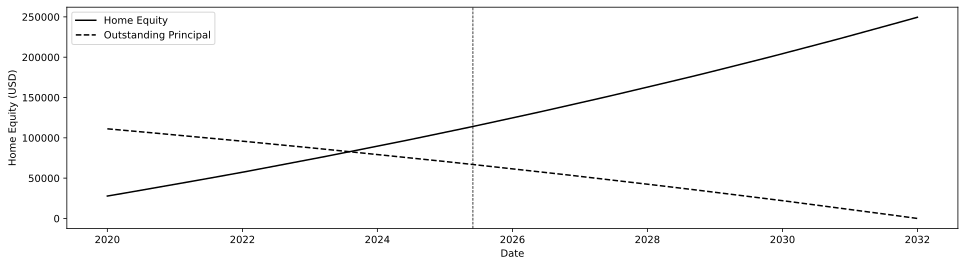

In [5]:
plt.figure(figsize=(16, 4))
plt.plot(home_equity['Date'], home_equity['Home Equity'], color='k', label='Home Equity')
plt.plot(home_equity['Date'], home_equity['Outstanding Principal'], color='k', linestyle="--", label='Outstanding Principal')
plt.axvline(pd.to_datetime('2025-06-01'), color='k', linewidth=0.75, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Home Equity (USD)')
plt.legend();

In [6]:
end_date = pd.to_datetime('2025-06-01')

current_home_value = home_equity[home_equity['Date'] == end_date]['Home Value'].values[0]
print(f"Home Value - Start (USD) = {property_val:,.2f}")
print(f"Home Value - Mid 2025 (USD) = {current_home_value:,.2f}")
print(f"Home Value - Start (AED) = {property_val / AED_USD:,.2f}")
print(f"Home Value - Mid 2025 (USD) = {current_home_value / AED_USD:,.2f}")
print(f"% Increase in Home Value = {current_home_value / property_val - 1:.2%}")
print()

print(f"Home Equity Value (USD) = {home_equity[home_equity['Date'] == end_date]['Home Equity'].values[0]:,.2f}")
print(f"Home Equity Value (AED) = {home_equity[home_equity['Date'] == end_date]['Home Equity'].values[0] / AED_USD:,.2f}")

total_investment = home_equity[home_equity['Date'] == end_date]['Month'].values[0] * emi + property_val * 0.2 + fees
print(f"Total Investment (USD) = {total_investment:,.2f}")
print(f"Total Investment (AED) = {total_investment / AED_USD:,.2f}")

print(f"Holding Period Return =")

Home Value - Start (USD) = 138,964.58
Home Value - Mid 2025 (USD) = 181,000.38
Home Value - Start (AED) = 510,000.00
Home Value - Mid 2025 (USD) = 664,271.39
% Increase in Home Value = 30.25%

Home Equity Value (USD) = 114,082.91
Home Equity Value (AED) = 418,684.27
Total Investment (USD) = 97,411.44
Total Investment (AED) = 357,500.00
Holding Period Return =


In [7]:
home_equity[home_equity['Date'] == end_date]

,Date,Month,Home Value,Outstanding Principal,Home Equity
65,2025-06-01,65,181000.377983,66917.470273,114082.90771


In [8]:
# Vanguard S&P 500 ETF (VOO)
snp500 = yf.Ticker("VOO")
start_date = "2020-01-01"
end_date = "2025-06-16"
snp500_hist = snp500.history(start=start_date, end=end_date)
snp500_hist.reset_index(inplace=True)

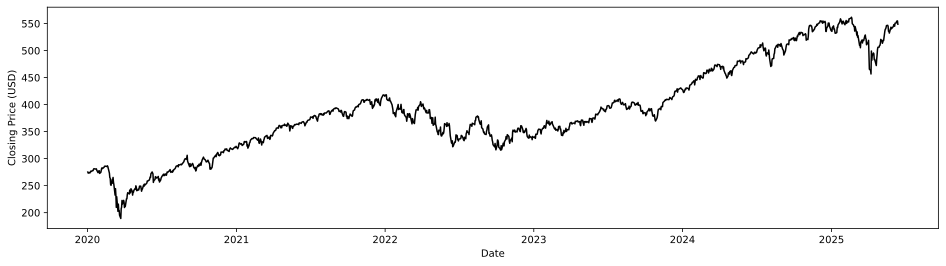

In [9]:
plt.figure(figsize=(16, 4))
plt.plot(snp500_hist['Date'], snp500_hist['Close'], color='k')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)');

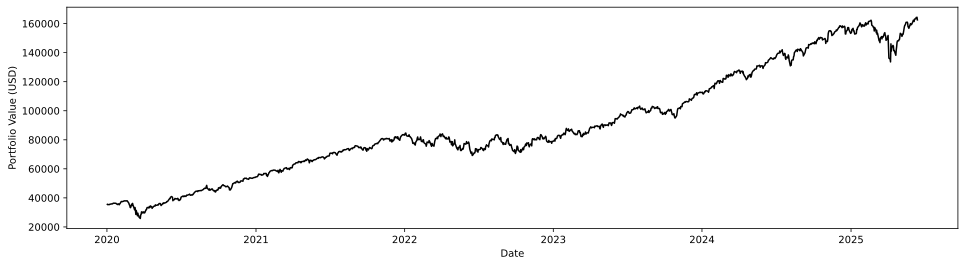

In [10]:
# Investment Portfolio
monthly_investment = (np.where(np.diff(snp500_hist['Date'].dt.month, prepend=1) != 0, emi, 0))
monthly_investment[0] = 130_000 * AED_USD

investment_df = pd.DataFrame()
investment_df['Date'] = snp500_hist['Date']
investment_df['Investments'] = monthly_investment
investment_df['Delta Shares'] = investment_df['Investments'] / snp500_hist['Open']
investment_df['Total Shares'] = investment_df['Delta Shares'].cumsum()
investment_df['Portfolio Value'] = investment_df['Total Shares'] * snp500_hist['Close']
investment_df['Avg Price'] = investment_df['Investments'].cumsum() / investment_df['Total Shares']
investment_df['Dividend Income'] = (investment_df['Total Shares'] * snp500_hist['Dividends']) * (1 - 0.3) # Withholding Tax 30%

plt.figure(figsize=(16, 4))
plt.plot(investment_df['Date'], investment_df['Portfolio Value'], color='k')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)');

In [11]:
print(f"Total Investment (USD) = {investment_df['Investments'].sum():,.2f}")
print(f"Total Investment (AED) = {investment_df['Investments'].sum() / AED_USD:,.2f}")

print(f"Portfolio Value (USD) = {investment_df['Portfolio Value'].to_numpy()[-1]:,.2f}")
print(f"Portfolio Value (AED) = {investment_df['Portfolio Value'].to_numpy()[-1] / AED_USD:,.2f}")

print(f"Dividend Income After Tax (USD) = {investment_df['Dividend Income'].sum():,.2f}")
print(f"Dividend Income After Tax (AED) = {investment_df['Dividend Income'].sum() / AED_USD:,.2f}")

Total Investment (USD) = 97,411.44
Total Investment (AED) = 357,500.00
Portfolio Value (USD) = 162,534.18
Portfolio Value (AED) = 596,500.45
Dividend Income After Tax (USD) = 4,993.99
Dividend Income After Tax (AED) = 18,327.95
